In [1]:
import pandas  as pd 

In [3]:
data = pd.read_csv('matches-selected-columns.csv')
data.head(10)

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score
0,Group stage,1.0,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0
1,Group stage,1.0,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0
2,Group stage,1.0,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0
3,Group stage,1.0,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0
4,Group stage,1.0,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0
5,Group stage,1.0,Sat,2026-06-13,18:00,Brazil,Morocco,1–1,1.0,1.0
6,Group stage,1.0,Sat,2026-06-13,21:00,Australia,Türkiye,2–0,2.0,0.0
7,Group stage,1.0,Sat,2026-06-13,21:00,Haiti,Scotland,0–1,0.0,1.0
8,Group stage,1.0,Sun,2026-06-14,12:00,Germany,Curaçao,7–1,7.0,1.0
9,Group stage,1.0,Sun,2026-06-14,15:00,Netherlands,Japan,2–2,2.0,2.0


In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   round       102 non-null    str    
 1   gameweek    102 non-null    float64
 2   dayofweek   102 non-null    str    
 3   date        102 non-null    str    
 4   start_time  102 non-null    str    
 5   home_team   102 non-null    str    
 6   away_team   102 non-null    str    
 7   score       102 non-null    str    
 8   home_score  102 non-null    float64
 9   away_score  102 non-null    float64
dtypes: float64(3), str(7)
memory usage: 13.1 KB


In [5]:
data.describe()

,gameweek,home_score,away_score
count,72.000000,98.000000,98.000000
mean,2.000000,1.744898,1.224490
std,0.822226,1.514951,1.162388
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000
50%,2.000000,1.000000,1.000000
75%,3.000000,3.000000,2.000000
max,3.000000,7.000000,5.000000


In [11]:
data['gameweek'] = data['gameweek'].fillna(data['gameweek'].mean())

In [13]:
data['home_score'] = data['home_score'].fillna(data['home_score'].min())
data['away_score'] = data['away_score'].fillna(data['away_score'].min())

In [ ]:

data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')


data['start_time'] = pd.to_datetime(data['start_time'], format='%H:%M').dt.time



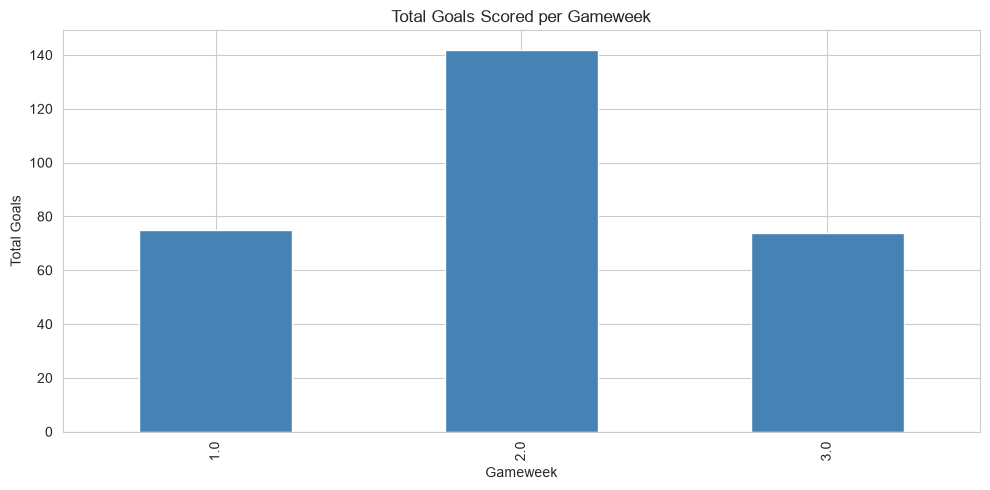

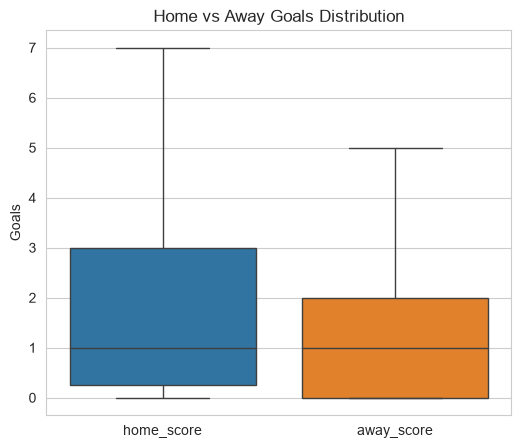

Home avg goals: 1.68
Away avg goals: 1.18


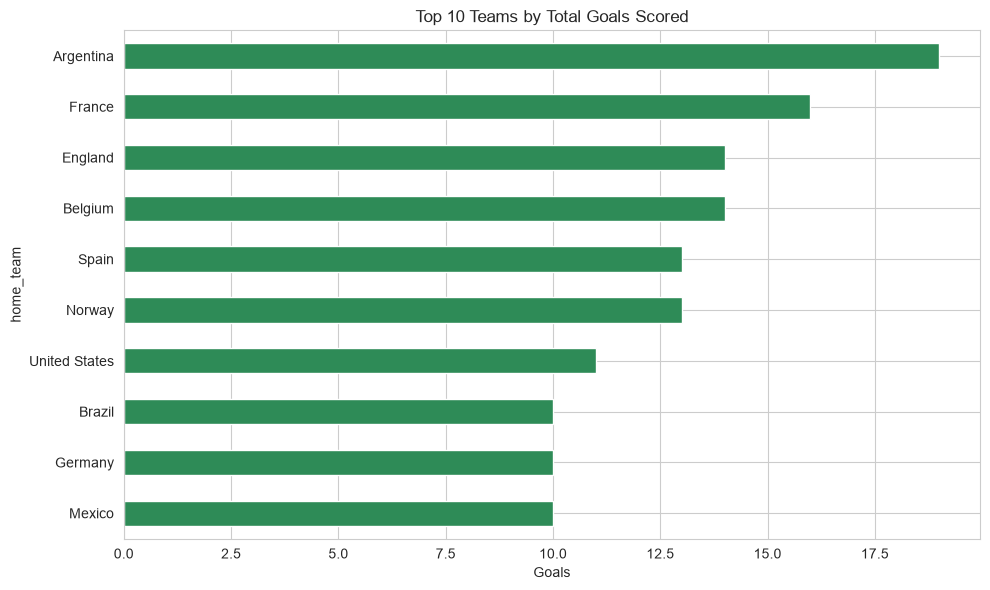

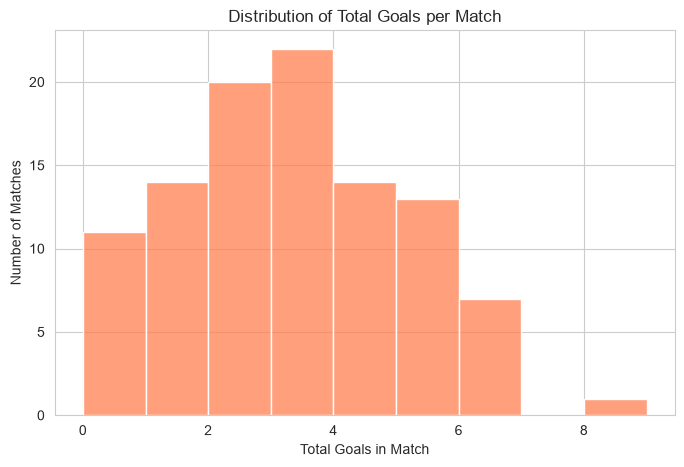

C:\Users\admin\AppData\Local\Temp\ipykernel_16208\3832276184.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='dayofweek', order=day_order, palette='viridis')


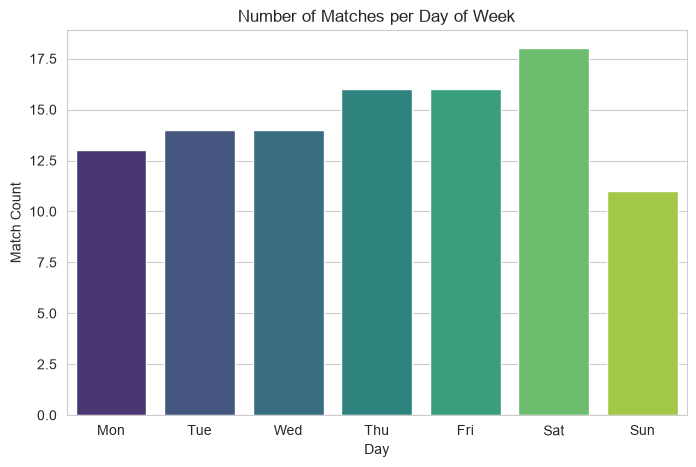

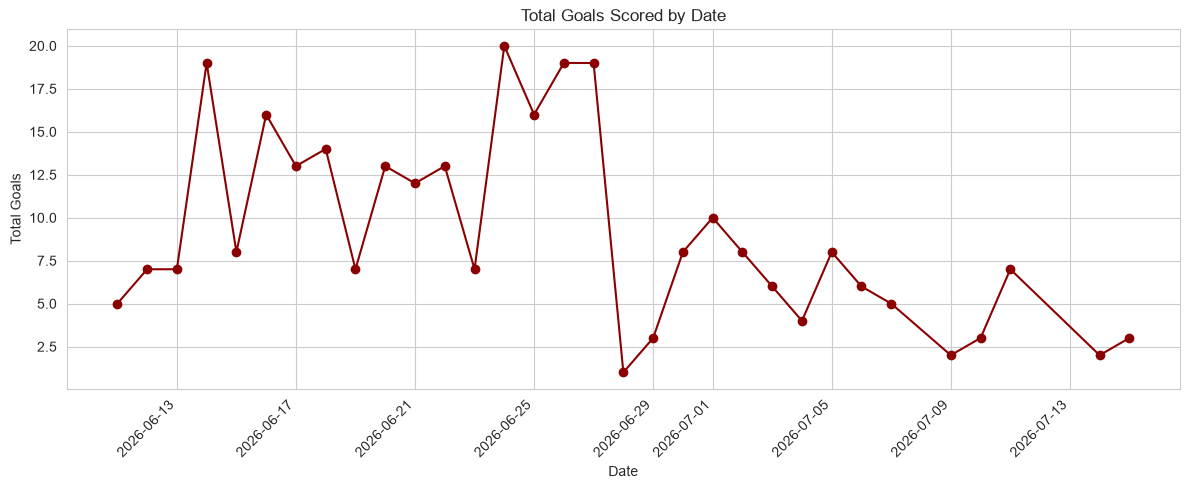

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

data['total_goals'] = data['home_score'] + data['away_score']
goals_per_gw = data.groupby('gameweek')['total_goals'].sum()

plt.figure(figsize=(10, 5))
goals_per_gw.plot(kind='bar', color='steelblue')
plt.title('Total Goals Scored per Gameweek')
plt.xlabel('Gameweek')
plt.ylabel('Total Goals')
plt.tight_layout()
plt.show()



plt.figure(figsize=(6, 5))
sns.boxplot(data=data[['home_score', 'away_score']])
plt.title('Home vs Away Goals Distribution')
plt.ylabel('Goals')
plt.show()

print("Home avg goals:", data['home_score'].mean().round(2))
print("Away avg goals:", data['away_score'].mean().round(2))



home_goals = data.groupby('home_team')['home_score'].sum()
away_goals = data.groupby('away_team')['away_score'].sum()
total_goals_by_team = home_goals.add(away_goals, fill_value=0).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
total_goals_by_team.head(10).plot(kind='barh', color='seagreen')
plt.title('Top 10 Teams by Total Goals Scored')
plt.xlabel('Goals')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))
sns.histplot(data['total_goals'], bins=range(0, int(data['total_goals'].max())+2), kde=False, color='coral')
plt.title('Distribution of Total Goals per Match')
plt.xlabel('Total Goals in Match')
plt.ylabel('Number of Matches')
plt.show()



plt.figure(figsize=(8, 5))
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.countplot(data=data, x='dayofweek', order=day_order, palette='viridis')
plt.title('Number of Matches per Day of Week')
plt.xlabel('Day')
plt.ylabel('Match Count')
plt.show()



goals_over_time = data.groupby('date')['total_goals'].sum()

plt.figure(figsize=(12, 5))
goals_over_time.plot(marker='o', color='darkred')
plt.title('Total Goals Scored by Date')
plt.xlabel('Date')
plt.ylabel('Total Goals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np


home_stats = data.groupby('home_team').agg(
    goals_for=('home_score', 'sum'),
    goals_against=('away_score', 'sum'),
    matches=('home_score', 'count')
)
away_stats = data.groupby('away_team').agg(
    goals_for=('away_score', 'sum'),
    goals_against=('home_score', 'sum'),
    matches=('away_score', 'count')
)

team_stats = home_stats.add(away_stats, fill_value=0)
team_stats['goal_diff'] = team_stats['goals_for'] - team_stats['goals_against']
team_stats['avg_goals_for'] = team_stats['goals_for'] / team_stats['matches']
team_stats['avg_goals_against'] = team_stats['goals_against'] / team_stats['matches']
team_stats['strength'] = team_stats['goal_diff'] / team_stats['matches']

team_stats.sort_values('strength', ascending=False, inplace=True)
print(team_stats.head(10))


def predict_match(team_a, team_b, stats, n_sims=10000):
    lam_a = stats.loc[team_a, 'avg_goals_for'] * (stats.loc[team_b, 'avg_goals_against'] + 0.1)
    lam_b = stats.loc[team_b, 'avg_goals_for'] * (stats.loc[team_a, 'avg_goals_against'] + 0.1)
    
    sims_a = np.random.poisson(lam_a, n_sims)
    sims_b = np.random.poisson(lam_b, n_sims)
    
    a_wins = (sims_a > sims_b).mean()
    b_wins = (sims_b > sims_a).mean()
    draws = (sims_a == sims_b).mean()
    
    print(f"{team_a} win: {a_wins:.1%}")
    print(f"{team_b} win: {b_wins:.1%}")
    print(f"Draw: {draws:.1%}")

predict_match('Argentina', 'Spain', team_stats)

             goals_for  goals_against  matches  goal_diff  avg_goals_for  \
home_team                                                                  
Argentina         19.0            7.0        7       12.0       2.714286   
France            16.0            4.0        7       12.0       2.285714   
Spain             13.0            1.0        7       12.0       1.857143   
Netherlands       10.0            4.0        4        6.0       2.500000   
Germany           10.0            4.0        4        6.0       2.500000   
Mexico            10.0            3.0        5        7.0       2.000000   
Brazil            10.0            4.0        5        6.0       2.000000   
Belgium           14.0            7.0        6        7.0       2.333333   
Portugal           8.0            3.0        5        5.0       1.600000   
England           14.0            8.0        7        6.0       2.000000   

             avg_goals_against  strength  
home_team                                 
A

In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# --- 1. Create the target: match result from home team's perspective ---
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

data['result'] = data.apply(get_result, axis=1)

# --- 2. Feature engineering: pre-match team strength (avoid leakage!) ---
# Build cumulative stats up to (not including) each match, ordered by date
data = data.sort_values('date').reset_index(drop=True)

team_goals_for = {}
team_goals_against = {}
team_matches = {}

home_strength = []
away_strength = []

for idx, row in data.iterrows():
    home, away = row['home_team'], row['away_team']
    
    h_matches = team_matches.get(home, 0)
    a_matches = team_matches.get(away, 0)
    
    h_avg = team_goals_for.get(home, 0) / h_matches if h_matches > 0 else 0
    a_avg = team_goals_for.get(away, 0) / a_matches if a_matches > 0 else 0
    
    home_strength.append(h_avg)
    away_strength.append(a_avg)
    
    # update stats AFTER using them for this row
    team_goals_for[home] = team_goals_for.get(home, 0) + row['home_score']
    team_goals_against[home] = team_goals_against.get(home, 0) + row['away_score']
    team_matches[home] = h_matches + 1
    
    team_goals_for[away] = team_goals_for.get(away, 0) + row['away_score']
    team_goals_against[away] = team_goals_against.get(away, 0) + row['home_score']
    team_matches[away] = a_matches + 1

data['home_avg_goals_pre'] = home_strength
data['away_avg_goals_pre'] = away_strength

# --- 3. Encode categorical features ---
le_home = LabelEncoder()
le_away = LabelEncoder()
data['home_team_enc'] = le_home.fit_transform(data['home_team'])
data['away_team_enc'] = le_away.fit_transform(data['away_team'])

features = ['home_team_enc', 'away_team_enc', 'home_avg_goals_pre', 'away_avg_goals_pre', 'gameweek']
X = data[features]
y = data['result']

# --- 4. Train/test split and model ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# --- 5. Feature importance ---
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

Accuracy: 0.47619047619047616
              precision    recall  f1-score   support

    Away Win       0.50      0.25      0.33         4
        Draw       0.00      0.00      0.00         5
    Home Win       0.53      0.75      0.62        12

    accuracy                           0.48        21
   macro avg       0.34      0.33      0.32        21
weighted avg       0.40      0.48      0.42        21

away_team_enc         0.290933
home_team_enc         0.290033
away_avg_goals_pre    0.202716
home_avg_goals_pre    0.167422
gameweek              0.048896
dtype: float64


In [20]:
def predict_final(home_team, away_team, model, le_home, le_away, team_goals_for, team_matches):
    h_avg = team_goals_for.get(home_team, 0) / team_matches.get(home_team, 1)
    a_avg = team_goals_for.get(away_team, 0) / team_matches.get(away_team, 1)
    
    X_new = pd.DataFrame({
        'home_team_enc': [le_home.transform([home_team])[0]],
        'away_team_enc': [le_away.transform([away_team])[0]],
        'home_avg_goals_pre': [h_avg],
        'away_avg_goals_pre': [a_avg],
        'gameweek': [7]  # final stage
    })
    
    proba = model.predict_proba(X_new)
    for cls, p in zip(model.classes_, proba[0]):
        print(f"{cls}: {p:.1%}")

predict_final('Argentina', 'Spain', rf, le_home, le_away, team_goals_for, team_matches)

Away Win: 6.8%
Draw: 17.9%
Home Win: 75.2%
